In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path
sys.path.append('/lab/barcheese01/smaffa/coTISja/src')

from scripts.plotting import *
from scripts.filter_utils import *
from scripts.analysis_pipelines import *
import re

import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option('display.max_columns', None)

In [3]:
experiment_table, _, replicate_df = load_experiment_manifest()
tis_type_frequency_order = ['Annotated', 'Truncated', 'Extended', 'uORF', 'Other']
tis_type_positional_order = ['uORF', 'Extended', 'Annotated', 'Truncated', 'Other']
codon_order = ['ATG', 'ATA', 'ATC', 'ATT', 'ACG', 'AAG', 'AGG', 'GTG', 'TTG', 'CTG']
sample_order = ['HeLa', 'K562', 'RPE1_Async', 'RPE1_Que', 'RPE1_Sen', 'U2OS']
cell_lines = ['HeLa', 'K562', 'RPE1_Async', 'U2OS']
rpe1_states = ['RPE1_Async', 'RPE1_Que', 'RPE1_Sen']

In [4]:
all_replicate_tis_df = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/filtered_tis_data/per_rep/all_samples_filtered_with_protein_seq.csv')
all_replicate_tis_df = all_replicate_tis_df.assign(
    IsoformID=all_replicate_tis_df['Tid'] + ':' + all_replicate_tis_df['Start'].astype(int).astype(str),
    TIS_ID=all_replicate_tis_df['Gid'] + ':' + all_replicate_tis_df['GenomeStart'],
    TIS=all_replicate_tis_df.apply(lambda x: f'{x["Tid"]}_{int(x["Start"])}_{x["GenomeStart"]}:{x["GenomePos"].split(":")[-1]}', axis=1)
)
tis_metadata = all_replicate_tis_df[
    ['TIS', 'Tid', 'Symbol', 'Gid', 'GeneType', 'GenomeStart', 'StartCodon', 'Start', 'RecatTISType', 'MANE_Select', 'AALen', 'AASeq']
].sort_values(by='AASeq').drop_duplicates(
    ['TIS']
)

In [5]:
all_replicate_tis_df = calculate_normalization_factors(
    all_replicate_tis_df, 
    id_columns = ['Sample', 'Replicate'],
    reference_sample = ('HeLa', 'rep1'),
    experiment_table=replicate_df[replicate_df['condition'] == 'TIS'].assign(rnaseq_count_file=lambda x: x['rnaseq_count_file'].apply(lambda y: [y])),
    id_cols = ['sample', 'replicate']
)

/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log

In [68]:
paired_isoform_df = pair_canonical_isoforms(
    all_replicate_tis_df, 
    id_columns=['Sample', 'Replicate', 'Tid']
)

/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Verify whether there are notable differences between AUG and non-AUG

Look at first upstream codon to control for leakiness effects

In [69]:
all_replicate_tis_df.value_counts('RecatTISType')

RecatTISType
Annotated    179408
Truncated    105436
Other         69463
Extended      44415
uORF          31404
Name: count, dtype: int64

In [70]:
first_codon_tis_ids = all_replicate_tis_df[
    (~all_replicate_tis_df['Imputed']) # &
    # (all_replicate_tis_df['MANE_Select'])
].sort_values(['Tid', 'Start']).drop_duplicates(subset=['Tid'])['TIS_ID'].tolist()

Text(0.5, 1.0, 'First detected TIS along transcript')

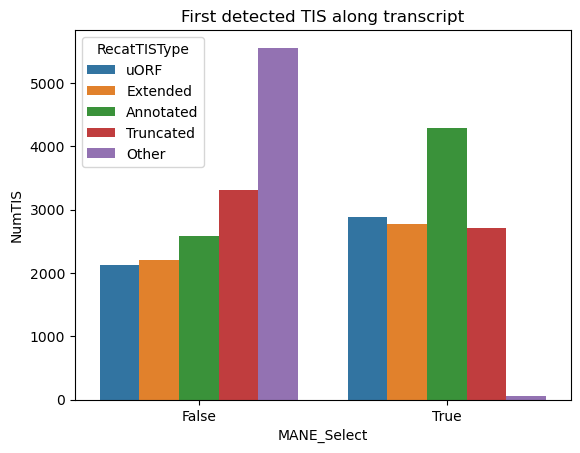

In [71]:
sns.barplot(
    all_replicate_tis_df[
        all_replicate_tis_df['TIS_ID'].isin(first_codon_tis_ids)
    ].drop_duplicates(subset=['TIS_ID']).value_counts(['MANE_Select', 'RecatTISType']).rename('NumTIS').reset_index(),
    x='MANE_Select', y='NumTIS', hue='RecatTISType', hue_order=tis_type_positional_order
)
plt.title('First detected TIS along transcript')

<Axes: xlabel='Sample', ylabel='SampleNormalizedTISCounts'>

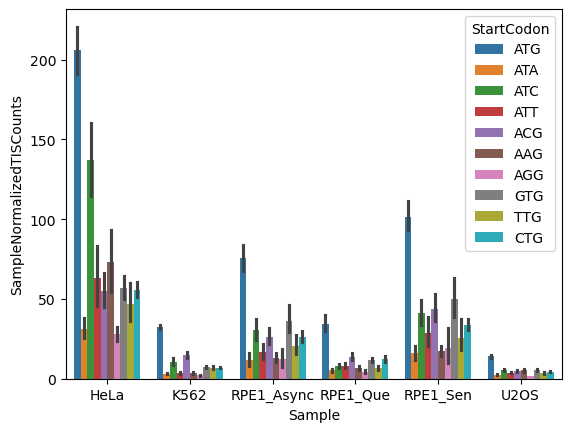

In [72]:
sns.barplot(
    all_replicate_tis_df[
        (~all_replicate_tis_df['Imputed']) &
        all_replicate_tis_df['TIS_ID'].isin(first_codon_tis_ids)
    ],
    x='Sample', y='SampleNormalizedTISCounts', hue='StartCodon', hue_order=codon_order
)

In [73]:
vst_log_te_matrix = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/translation_efficiency_vst_matrix.csv', index_col=0)
riboseq_counts = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rpf_summed_replicate_counts.csv', index_col=0)
tis_mask = riboseq_counts >= 5
rna_counts = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rna_summed_replicate_counts.csv', index_col=0)
rna_mask = rna_counts >= 5
masked_te_matrix = vst_log_te_matrix[tis_mask & rna_mask].dropna(how='all')

<Axes: xlabel='Sample', ylabel='LogTE'>

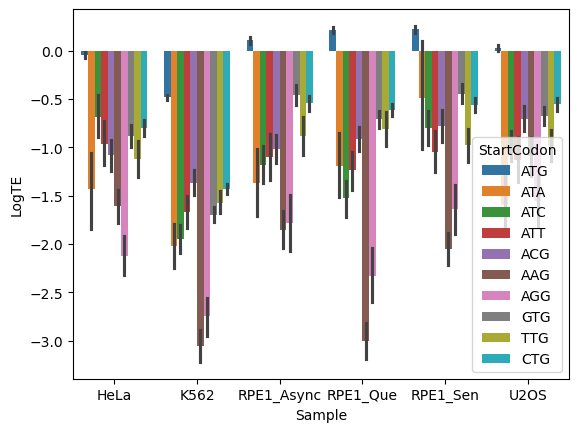

In [82]:
sns.barplot(
    all_replicate_tis_df[
        (~all_replicate_tis_df['Imputed']) &
        all_replicate_tis_df['TIS_ID'].isin(first_codon_tis_ids)
    ].merge(masked_te_matrix.melt(
        var_name='Sample', value_name='LogTE', ignore_index=False).reset_index(), left_on=['Sample', 'TIS'], right_on=['Sample', 'TIS']
    ).groupby(['Sample', 'TIS']).first().reset_index(),
    x='Sample', y='LogTE', hue='StartCodon', hue_order=codon_order
)

# Leaky scanning model 1:

We propose that the strength of translation at the canonical site is dependent on the length of the 5'UTR, the number of upstream alternative TISs (including uORFs), the identity of the start codons at the upstream aTISs, and the Kozak sequence similarity at the canonical site. The effects of each of these factors may be stronger or weaker in different cell lines.

This supposes the following model:

riboseq_counts ~ B0 + B1 * Kozak + B2 * N_upstream + B3 * N_AUG_alt + B4 * N_AUC_alt + ... + B(10?) * canonical_UTR_length + B11 * min_uORF_UTR_length + B12 * sample + B13 * sample:features...

## Step 1: Create a reference set of TIS sequences common to all samples (same reference genome)

In [5]:
vst_log_te_matrix = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/translation_efficiency_vst_matrix.csv', index_col=0)
riboseq_counts = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rpf_summed_replicate_counts.csv', index_col=0)
tis_mask = riboseq_counts >= 5
rna_counts = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rna_summed_replicate_counts.csv', index_col=0)
rna_mask = rna_counts >= 5
masked_te_matrix = vst_log_te_matrix[tis_mask & rna_mask].dropna(how='all')

In [6]:
tis_with_sufficient_support_in_any_line = masked_te_matrix.index.tolist()

In [7]:
def define_global_tis_reference(longform_tis_table, masked_logte_matrix, sample_subset=None):
    if sample_subset is None: 
        sample_subset = masked_logte_matrix.columns.tolist()
    tis_with_sufficient_support = masked_logte_matrix[sample_subset].dropna(how='all').index.tolist() # TE defined in any line
    filtered_longform_tis_table = longform_tis_table[
        longform_tis_table['Sample'].isin(sample_subset) & 
        longform_tis_table['TIS'].isin(tis_with_sufficient_support)
    ].copy()
    filtered_longform_tis_table['GenomeStart'] = filtered_longform_tis_table['TIS'].str.split('_').str[-1]
    filtered_longform_tis_table['ChromosomePosition'] = filtered_longform_tis_table['GenomeStart'].str.split(':').str[1].astype(int)
    filtered_longform_tis_table['Orientation'] = filtered_longform_tis_table['GenomeStart'].str.split(':').str[-1]

    transcript_to_tis_vector_information = []
    tis_groups = filtered_longform_tis_table.groupby('Tid').groups
    for tid, tid_idxs in tqdm(tis_groups.items()):
        tid_subset = filtered_longform_tis_table.loc[tid_idxs, :]
        if tid_subset.iloc[0].loc['Orientation'] == '+': # forward, use an ascending sort on the chromosome position
            sort_ascending = True
        else:
            sort_ascending = False
        tid_subset_ordered = tid_subset.sort_values('ChromosomePosition', ascending=sort_ascending)
        ordered_unique_tis_subset = tid_subset_ordered.drop_duplicates(subset=['GenomeStart'])
        codon_string = '|'.join([s for s in ordered_unique_tis_subset['StartCodon'].tolist()])
        utr_length_string = '|'.join([str(int(s)) for s in ordered_unique_tis_subset['Start'].tolist()])
        tistype_string = '|'.join([s for s in ordered_unique_tis_subset['RecatTISType'].tolist()])
        transcript_to_tis_vector_information.append([tid, utr_length_string, codon_string, tistype_string])
    transcript_to_tis_vector_information = pd.DataFrame(transcript_to_tis_vector_information, columns=['Tid', 'UTRLengths', 'StartCodons', 'TISTypes'])
    return transcript_to_tis_vector_information


In [ ]:
global_tis_reference = define_global_tis_reference(all_replicate_tis_df, masked_te_matrix)
# global_tis_reference.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/transcript_tis_vector_annotations.csv', index=False)

100%|██████████| 43123/43123 [02:13<00:00, 323.42it/s]


In [40]:
global_tis_reference = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/transcript_tis_vector_annotations.csv')[
    ['Tid', 'UTRLengths', 'StartCodons', 'TISTypes']
]

In [42]:
from Bio import SeqIO, SeqUtils

def read_trancript_sequences(transcript_fasta='/lab/barcheese01/smaffa/coTISja/data/reference/gencode.v49.pc_transcripts.fa'):
    gencode_transcript_sequences = dict()
    for record in SeqIO.parse(transcript_fasta, format='fasta'):
        sequence_ids = record.id
        transcript_id = [tag for tag in sequence_ids.split('|') if 'ENST' in tag][0]
        gencode_transcript_sequences[transcript_id] = str(record.seq)
    gencode_transcript_sequences = pd.DataFrame(pd.Series(gencode_transcript_sequences), columns=['Seq']).reset_index(names=['Tid'])
    gencode_transcript_sequences['Len'] = gencode_transcript_sequences['Seq'].apply(lambda x: len(x))
    return gencode_transcript_sequences

# Define IUPAC ambiguity codes
ambiguity_dict = {
    'A': {'A'}, 'C': {'C'}, 'G': {'G'}, 'T': {'T'}, 'U': {'T'},
    'R': {'A', 'G'}, 'Y': {'C', 'T'}, 'M': {'A', 'C'},
    'K': {'G', 'T'}, 'S': {'C', 'G'}, 'W': {'A', 'T'},
    'B': {'C', 'G', 'T'}, 'D': {'A', 'G', 'T'}, 'H': {'A', 'C', 'T'},
    'V': {'A', 'C', 'G'}, 'N': {'A', 'C', 'G', 'T'},
    'a': {'A'}, 'c': {'C'}, 'g': {'G'}, 't': {'T'}, 'u': {'T'}
}

kozak_pattern = 'gccgccRccATGG'
partial_weights = [0.1,0.1,0.1,0.1,0.1,0.1,1,0.1,0.1,1,1,1,1]
major_weights = [0,0,0,0,0,0,1,0,0,1,1,1,1]

def hamming_distance_ambiguous(s1, s2, weights=None):
    """Calculate Hamming distance between two sequences with ambiguous bases."""
    if len(s1) != len(s2):
        raise ValueError("Sequences must be of equal length")
    
    if weights is None:
        weights = [1] * len(s1)

    distance = 0
    position_i = 0
    for a, b in zip(s1, s2):
        set_a = ambiguity_dict.get(a, {a})
        set_b = ambiguity_dict.get(b, {b})
        if not set_a.intersection(set_b):  # No overlap → mismatch
            distance += weights[position_i]
        position_i += 1
    return distance

In [43]:
reference_transcript_sequences = read_trancript_sequences()

In [51]:
def assign_canonical_kozak_annotations(tis_vector_annotations, transcript_sequences):
    annotated_tis_vector_metadata = tis_vector_annotations.merge(transcript_sequences, left_on='Tid', right_on='Tid', how='left')

    canonical_subset = annotated_tis_vector_metadata[
        annotated_tis_vector_metadata['TISTypes'].str.contains('Annotated')
    ].copy()
    canonical_subset['CanonicalIndex'] = canonical_subset['TISTypes'].apply(lambda x: x.split('|').index('Annotated'))
    canonical_subset['CanonicalStart'] = canonical_subset.apply(lambda x: int(x['UTRLengths'].split('|')[int(x['CanonicalIndex'])]), axis=1)
    canonical_subset['CanonicalKozakContext'] = canonical_subset.apply(
        lambda x: x['Seq'][(int(x['CanonicalStart']) - 9):(int(x['CanonicalStart']) + 4)], axis=1
    )
    canonical_subset['GCContentCanonicalUTR'] = canonical_subset.apply(
        lambda x: SeqUtils.gc_fraction(x['Seq'][:(int(x['CanonicalStart']))]), axis=1
    )

    annotated_tis_vector_metadata = annotated_tis_vector_metadata.merge(canonical_subset, how='left')
    hamming_subset = annotated_tis_vector_metadata[
        annotated_tis_vector_metadata['CanonicalKozakContext'].apply(lambda x: len(x) == 13 if isinstance(x, str) else False)
    ].copy()
    hamming_subset['KozakHammingDistance'] = hamming_subset.apply(
        lambda x: hamming_distance_ambiguous(kozak_pattern, x['CanonicalKozakContext'], weights=None), axis=1
    )
    hamming_subset['KozakMajorHammingDistance'] = hamming_subset.apply(
        lambda x: hamming_distance_ambiguous(kozak_pattern, x['CanonicalKozakContext'], weights=major_weights), axis=1
    )

    annotated_tis_vector_metadata = annotated_tis_vector_metadata.merge(hamming_subset, how='left')
    return annotated_tis_vector_metadata


In [52]:
global_tis_reference_df = assign_canonical_kozak_annotations(global_tis_reference, reference_transcript_sequences)
global_tis_reference_df.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/transcript_tis_vector_annotations.csv', index=False)

## Step 2: Featurize the replicate data

In [53]:
def featurize_by_canonical_sites(tid_summary_metadata, tis_df, 
                                 sample_id_columns=['Sample', 'Replicate'], 
                                 response_variable_columns=['TISCounts', 'GeneRNASeqCounts', 'GeneRNASeqLogRPM'], 
                                 extra_transcript_columns=['MANE_Select']):
    
    # extract features from the annotation metadata summary
    canonical_subset = tid_summary_metadata[
        tid_summary_metadata['TISTypes'].str.contains('Annotated')
    ].dropna()

    predictors_table = pd.concat([
        canonical_subset['Tid'],
        canonical_subset.apply(lambda x: len(x['StartCodons'].split('|')[:int(x['CanonicalIndex'])]), axis=1).rename('NumUpstreamTIS'),
    ] + [
        canonical_subset.apply(lambda x: len([y for y in x['StartCodons'].split('|')[:int(x['CanonicalIndex'])] if y == codon]), axis=1).rename(f'NumUpstream{codon}') for codon in codon_order
    ] + [
        canonical_subset.apply(lambda x: len([y for y in x['StartCodons'].split('|')[:int(x['CanonicalIndex'])] if y == tistype]), axis=1).rename(f'NumUpstream{tistype}') for tistype in ['uORF', 'Extension', 'Other']
    ] + [
        canonical_subset['UTRLengths'].apply(lambda x: int(x.split('|')[0])).rename('FirstUTRLength'),
        canonical_subset.apply(lambda x: int(x['UTRLengths'].split('|')[int(x['CanonicalIndex'])]), axis=1).rename('CanonicalUTRLength'),
        canonical_subset['GCContentCanonicalUTR'],
        canonical_subset['KozakHammingDistance'],
        canonical_subset['KozakMajorHammingDistance']
    ], axis=1)

    # extract observations from the longform tis df
    observations_table = tis_df[
        tis_df['Tid'].isin(canonical_subset['Tid']) &
        (tis_df['RecatTISType'] == 'Annotated')
    ][['Tid'] + sample_id_columns + response_variable_columns + extra_transcript_columns]

    feature_table = observations_table.merge(predictors_table, left_on='Tid', right_on='Tid', how='outer')
    return feature_table

In [54]:
feature_table = featurize_by_canonical_sites(tid_summary_metadata=global_tis_reference_df, tis_df=all_replicate_tis_df)

In [56]:
feature_table.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/glm_model_inputs.csv', index=False)

## Step 3: Fit the GLM

In [11]:
feature_table = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/translation_models/glm_model_inputs.csv')
feature_table = feature_table.assign(
    CanonicalUTRLength = lambda x: x['CanonicalUTRLength'] / 1000,
    NumUpstreamNonATG=lambda x: x['NumUpstreamTIS'] - x['NumUpstreamATG']
)

from sklearn.preprocessing import StandardScaler
feature_table_scaled = feature_table.copy()

cols_to_scale = [
    "FirstUTRLength",
    "CanonicalUTRLength",
    "KozakHammingDistance",
    "KozakMajorHammingDistance"
]

scaler = StandardScaler()
feature_table_scaled[cols_to_scale] = scaler.fit_transform(feature_table_scaled[cols_to_scale])

In [12]:
model = smf.glm(
    # formula="""
    # TISCounts ~ 
    #     KozakMajorHammingDistance +
    #     NumUpstreamATG +
    #     NumUpstreamNonATG +
    #     CanonicalUTRLength +
    #     GCContentCanonicalUTR + 
    #     Sample +
    #     KozakMajorHammingDistance:Sample +
    #     NumUpstreamATG:Sample +
    #     NumUpstreamNonATG:Sample +
    #     CanonicalUTRLength:Sample + 
    #     GCContentCanonicalUTR:Sample
    # """,
    formula="""
    TISCounts ~ 
        KozakMajorHammingDistance +
        NumUpstreamATG +
        NumUpstreamNonATG +
        CanonicalUTRLength +
        Sample +
        KozakMajorHammingDistance:Sample +
        NumUpstreamATG:Sample +
        NumUpstreamNonATG:Sample +
        CanonicalUTRLength:Sample
    """,
    data=feature_table,
    family=sm.families.NegativeBinomial(),
    offset=feature_table["GeneRNASeqLogRPM"]
).fit(cov_type='HC0')

print(model.summary())

/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:              TISCounts   No. Observations:               138190
Model:                            GLM   Df Residuals:                   138160
Model Family:        NegativeBinomial   Df Model:                           29
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -9.9729e+05
Date:                Tue, 24 Mar 2026   Deviance:                   9.9301e+05
Time:                        00:23:15   Pearson chi2:                 2.87e+08
No. Iterations:                   100   Pseudo R-squ. (CS):             0.8491
Covariance Type:                  HC0                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [18]:
def write_glm_results(model, output_dir, model_prefix):
    summary_file = os.path.join(output_dir, f'{model_prefix}_model_summary.csv')
    covariance_file = os.path.join(output_dir, f'{model_prefix}_covariance_matrix.csv')
    with open(summary_file, "w") as f:
        f.write(model.summary().as_csv())
    model.cov_params().to_csv(covariance_file, index=True)

In [19]:
write_glm_results(model, output_dir='/lab/barcheese01/smaffa/coTISja/data/translation_models', model_prefix='canonical_translation')

In [63]:
pearson_resid = model.resid_pearson
dispersion = (pearson_resid**2).sum() / model.df_resid

print(dispersion)

1390.7598140086563


### Explicit NB model, rather than GLM with NB link

This should allow for dispersion estimates per transcript, unlike the GLM which uses a fixed dispersion (variance/mean) parameter of alpha=1, which is almost certainly an underestimate of the true dispersion.

In [99]:
def create_model_inputs(feature_df, formula_string):
    from pandas.api.types import is_string_dtype

    exog_var = formula_string.split('~')[0].strip()
    endog_var_list = [term.strip() for term in formula_string.split('~')[-1].split('+')]
    noninteraction_terms = [term for term in endog_var_list if ':' not in term]
    interaction_terms = [(combo.split(':')[0].strip(), combo.split(':')[1].strip()) for combo in endog_var_list if ':' in combo]
    products = {f'{s[0]}__x__{s[1]}': s for s in interaction_terms}
    all_columns = list(set(noninteraction_terms + [s[0] for s in interaction_terms] + [s[1] for s in interaction_terms]))
    categorical_columns = [col for col in all_columns if is_string_dtype(feature_df[col])]
    categorical_to_categories = {col: sorted(feature_df[col].unique().tolist()) for col in categorical_columns}
    categorical_to_reference_value = {col: cats[0] for col, cats in categorical_to_categories.items()}
    categorical_to_other_values = {col: cats[1:] for col, cats in categorical_to_categories.items()}

    if len(categorical_columns) > 0:
        categorical_encodings = pd.concat([
            pd.get_dummies(feature_df[col]).drop([categorical_to_reference_value[col]], axis=1).rename(
                {cat: f'{col}[T.{cat}]' for cat in categorical_to_other_values[col]}, axis=1
            ) for col in categorical_columns
        ], axis=1)
    else:
        categorical_encodings = pd.DataFrame()

    interaction_encodings = []
    for prod, pair in products.items():
        s1, s2 = pair
        if s1 in categorical_columns and s2 in categorical_columns:
            for cat1 in categorical_to_other_values[s1]:
                for cat2 in categorical_to_other_values[s2]:
                    interaction_encodings.append((categorical_encodings[f'{s1}[T.{cat1}]'] * categorical_encodings[f'{s2}[{cat2}]']).rename(f'{s1}[T.{cat1}]__x__{s2}[T.{cat2}]'))
        elif s1 in categorical_columns:
            for cat in categorical_to_other_values[s1]:
                interaction_encodings.append((categorical_encodings[f'{s1}[T.{cat}]'] * feature_df[s2]).rename(f'{s1}[T.{cat}]__x__{s2}'))
        elif s2 in categorical_columns:
            for cat in categorical_to_other_values[s2]:
                interaction_encodings.append((feature_df[s1] * categorical_encodings[f'{s2}[T.{cat}]']).rename(f'{s1}__x__{s2}[T.{cat}]'))
        else:
            interaction_encodings.append((feature_df[s1] * feature_df[s2]).rename(f'{s1}__x__{s2}'))
    interaction_encodings = pd.concat(interaction_encodings, axis=1)

    endog_df = pd.concat([
        categorical_encodings
    ] + [
        feature_df[col] for col in noninteraction_terms if col not in categorical_columns
    ] + [
        interaction_encodings
    ], axis=1)
    exog_df = feature_df[exog_var]

    return endog_df.astype(float), exog_df.astype(float)

In [100]:
formula = 'TISCounts' + '~' + '+'.join([
    'KozakHammingDistance', 'NumUpstreamATG', 'NumUpstreamNonATG', 'CanonicalUTRLength', 'Sample',
    'KozakHammingDistance:Sample', 'NumUpstreamATG:Sample', 'NumUpstreamNonATG:Sample', 'CanonicalUTRLength:Sample'
])

X, y = create_model_inputs(
    feature_table_scaled.assign(NumUpstreamNonATG=lambda x: x['NumUpstreamTIS'] - x['NumUpstreamATG']), formula
)

In [101]:
beta_test = np.ones(X.shape[1])
linpred = X.values @ beta_test
print(linpred.min(), linpred.max())

-6.537045530906099 43.91158967638068


In [104]:
X.describe()

,Sample[T.K562],Sample[T.RPE1_Async],Sample[T.RPE1_Que],Sample[T.RPE1_Sen],Sample[T.U2OS],KozakHammingDistance,NumUpstreamATG,NumUpstreamNonATG,CanonicalUTRLength,KozakHammingDistance__x__Sample[T.K562],KozakHammingDistance__x__Sample[T.RPE1_Async],KozakHammingDistance__x__Sample[T.RPE1_Que],KozakHammingDistance__x__Sample[T.RPE1_Sen],KozakHammingDistance__x__Sample[T.U2OS],NumUpstreamATG__x__Sample[T.K562],NumUpstreamATG__x__Sample[T.RPE1_Async],NumUpstreamATG__x__Sample[T.RPE1_Que],NumUpstreamATG__x__Sample[T.RPE1_Sen],NumUpstreamATG__x__Sample[T.U2OS],NumUpstreamNonATG__x__Sample[T.K562],NumUpstreamNonATG__x__Sample[T.RPE1_Async],NumUpstreamNonATG__x__Sample[T.RPE1_Que],NumUpstreamNonATG__x__Sample[T.RPE1_Sen],NumUpstreamNonATG__x__Sample[T.U2OS],CanonicalUTRLength__x__Sample[T.K562],CanonicalUTRLength__x__Sample[T.RPE1_Async],CanonicalUTRLength__x__Sample[T.RPE1_Que],CanonicalUTRLength__x__Sample[T.RPE1_Sen],CanonicalUTRLength__x__Sample[T.U2OS]
count,138190.000000,138190.000000,138190.000000,138190.000000,138190.000000,1.381900e+05,138190.000000,138190.000000,1.381900e+05,138190.000000,138190.000000,138190.000000,138190.000000,138190.000000,138190.000000,138190.000000,138190.000000,138190.000000,138190.000000,138190.000000,138190.000000,138190.000000,138190.000000,138190.000000,138190.000000,138190.000000,138190.000000,138190.000000,138190.000000
mean,0.290195,0.089334,0.139460,0.092025,0.219053,-1.085944e-16,0.129177,0.816962,-5.429721e-17,0.012592,-0.003142,-0.003896,-0.004342,-0.005020,0.038773,0.010970,0.017606,0.012425,0.027209,0.208742,0.083226,0.120153,0.083870,0.176011,0.001885,0.000973,-0.000013,0.000454,-0.003959
std,0.453854,0.285226,0.346427,0.289063,0.413606,1.000004e+00,0.386051,1.241997,1.000004e+00,0.539239,0.299368,0.376199,0.303311,0.464246,0.219472,0.117608,0.150840,0.125245,0.184298,0.702786,0.476285,0.559592,0.475571,0.664941,0.541407,0.303415,0.372682,0.304296,0.460769
min,0.000000,0.000000,0.000000,0.000000,0.000000,-2.963251e+00,0.000000,0.000000,-8.099748e-01,-2.963251,-2.963251,-2.963251,-2.963251,-2.963251,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.809975,-0.809975,-0.809975,-0.809975,-0.809975
25%,0.000000,0.000000,0.000000,0.000000,0.000000,-7.388440e-01,0.000000,0.000000,-5.642207e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,-1.827422e-01,0.000000,0.000000,-2.737840e-01,0.000000,0.000000,-0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000,0.000000,0.000000,9.294615e-01,0.000000,1.000000,2.388896e-01,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,-0.000000,0.000000,-0.000000,-0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,2.597767e+00,4.000000,13.000000,2.041660e+01,2.597767,2.597767,2.597767,2.597767,2.597767,4.000000,4.000000,4.000000,4.000000,4.000000,13.000000,13.000000,13.000000,13.000000,13.000000,20.416595,19.720488,19.720488,19.720488,19.720488


In [102]:
nb_model = sm.NegativeBinomial(
    endog=y,
    exog=X,
    offset=feature_table["GeneRNASeqLogRPM"]
).fit()

print(nb_model.summary())

/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:3384: RuntimeWarning: overflow encountered in exp
  alpha = np.exp(params[-1])
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:3377: RuntimeWarning: invalid value encountered in subtract
  coeff = (gamma_ln(size+endog) - gamma_ln(endog+1) -
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.

         Current function value: nan
         Iterations: 0
         Function evaluations: 1
         Gradient evaluations: 1


/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:3614: RuntimeWarning: divide by zero encountered in log
  np.log(prob) - (y - mu)/(a1+mu))
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:3613: RuntimeWarning: invalid value encountered in add
  dalpha = da1 * (dgpart +
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:3615: RuntimeWarning: invalid value encountered in subtract
  dada = (da2 * dalpha/da1 + da1**2 * (special.polygamma(1, a1+y) -
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:3616: RuntimeWarning: divide by zero encountered in scalar divide
  special.polygamma(1, a1) + 1/a1 - 1/(a1 + mu) +
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:361

                     NegativeBinomial Regression Results                      
Dep. Variable:              TISCounts   No. Observations:               138190
Model:               NegativeBinomial   Df Residuals:                   138161
Method:                           MLE   Df Model:                           28
Date:                Fri, 20 Mar 2026   Pseudo R-squ.:                     nan
Time:                        00:23:25   Log-Likelihood:                    nan
converged:                      False   LL-Null:                   -7.5828e+05
Covariance Type:            nonrobust   LLR p-value:                       nan
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Sample[T.K562]                                   -2.1837        nan        nan        nan         nan         nan
Sample[T.RPE1_Async]      

This model does not fit well because of overflow issues, I suspect due to differences in variances between predictors

## Step 4: Extract relevant coefficients for interpretation & F tests for predictor relevance

In [22]:
def compute_fold_changes(result, factor_names, cell_lines, baseline_cell_line):
    """
    Computes fold-change and 95% CI for specified factors per cell line.
    
    Parameters:
        result: fitted GLM NB (with cov_type='HC0')
        factor_names: list of main factors to interpret
        cell_lines: list of all samples
        baseline_cell_line: the reference sample
    Returns:
        pandas DataFrame with β, fold-change, 95% CI per factor per cell line
    """
    cov = result.cov_params()
    params = result.params
    
    records = []

    for factor in factor_names:
        # main effect
        beta_main = params.get(factor, 0.0)
        
        for cell_line in cell_lines:
            # start with main effect
            beta_eff = beta_main
            
            if cell_line != baseline_cell_line:
                # check for interaction term
                interaction_term = f"{factor}:Sample[T.{cell_line}]"
                beta_int = params.get(interaction_term, 0.0)
                beta_eff += beta_int
                
                # variance propagation
                sub_cov = cov.reindex(index=[factor, interaction_term], columns=[factor, interaction_term], fill_value=0.0)

                var_eff = sub_cov.loc[factor, factor] + sub_cov.loc[interaction_term, interaction_term] + 2 * sub_cov.loc[factor, interaction_term]
            else:
                # baseline cell line variance
                var_eff = cov.loc[factor, factor]
            
            se_eff = np.sqrt(var_eff)
            # 95% CI in log space
            ci_low = beta_eff - 1.96 * se_eff
            ci_high = beta_eff + 1.96 * se_eff
            
            # convert to fold-change
            fold = np.exp(beta_eff)
            fold_low = np.exp(ci_low)
            fold_high = np.exp(ci_high)
            
            records.append({
                'sample': cell_line,
                'factor': factor,
                'beta': beta_eff,
                'fold_change': fold,
                'fold_change_CI_low': fold_low,
                'fold_change_CI_high': fold_high
            })
    
    return pd.DataFrame.from_records(records)

def plot_forest(fold_change_table, log_scale=True, figsize=(8,6), title="Forest Plot of Factor Effects"):
    """
    Creates a forest plot of fold-change effects per factor per cell line.
    
    Parameters:
        fold_change_table: DataFrame with columns: ['cell_line', 'factor', 'fold_change', 'fold_change_CI_low', 'fold_change_CI_high']
        log_scale: whether to plot on log scale
        figsize: figure size
        title: plot title
    """
    df = fold_change_table.copy()
    
    # log transform if desired
    if log_scale:
        df['x'] = np.log(df['fold_change'])
        df['x_low'] = np.log(df['fold_change_CI_low'])
        df['x_high'] = np.log(df['fold_change_CI_high'])
        df['err_low'] = df['x'] - df['x_low']
        df['err_high'] = df['x_high'] - df['x']
        ref_line = 0
        xlabel = 'Log Fold-Change'
    else:
        df['x'] = df['fold_change']
        df['err_low'] = df['fold_change'] - df['fold_change_CI_low']
        df['err_high'] = df['fold_change_CI_high'] - df['fold_change']
        ref_line = 1
        xlabel = 'Fold-Change'
    
    # create a numeric y-position
    df['y_pos'] = df.groupby('factor').cumcount()
    # adjust spacing to separate factors
    factor_offsets = {f:i*(df['y_pos'].max()+2) for i,f in enumerate(df['factor'].unique())}
    df['y'] = df.apply(lambda r: r['y_pos'] + factor_offsets[r['factor']], axis=1)
    
    plt.figure(figsize=figsize)
    
    # color palette
    palette = sns.color_palette("Set2", n_colors=len(df['factor'].unique()))
    factor_colors = dict(zip(df['factor'].unique(), palette))
    
    # plot points and error bars
    for idx, row in df.iterrows():
        plt.errorbar(row['x'], row['y'], xerr=[[row['err_low']], [row['err_high']]],
                     fmt='o', color=factor_colors[row['factor']], capsize=4)
    
    # y-ticks: show cell line names where possible
    # to avoid overlaps, only show the first occurrence per factor
    yticks = []
    yticklabels = []
    for f in df['factor'].unique():
        sub = df[df['factor'] == f]
        for _, r in sub.iterrows():
            yticks.append(r['y'])
            yticklabels.append(f"{r['sample']}")
    
    plt.yticks(yticks, yticklabels)
    
    # reference line
    plt.axvline(ref_line, color='gray', linestyle='--')
    
    plt.xlabel(xlabel)
    plt.ylabel('Cell line')
    plt.title(title)
    
    # legend
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8)
               for c in palette]
    plt.legend(handles, df['factor'].unique(), title='Factor', bbox_to_anchor=(1.05,1), loc='upper left')
    
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

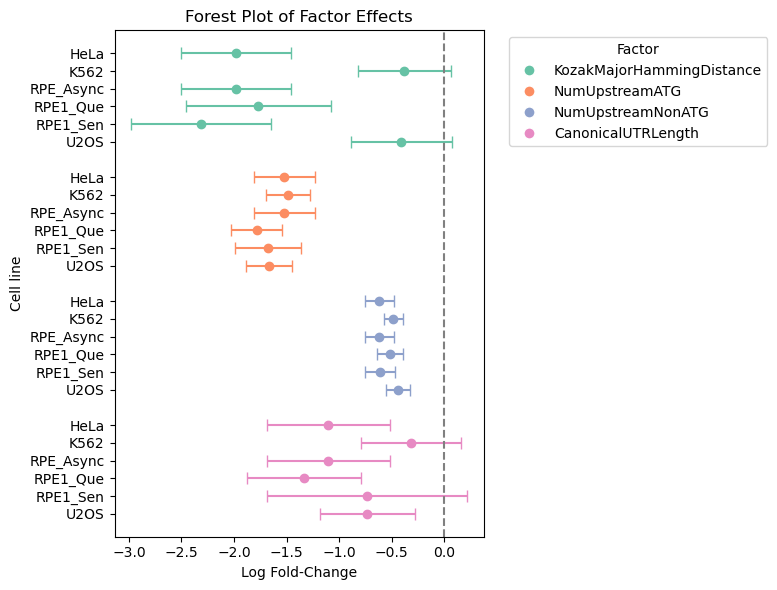

In [13]:
fold_change_table = compute_fold_changes(
    model, feature_table, 
    # ['KozakMajorHammingDistance', 'NumUpstreamATG', 'NumUpstreamNonATG', 'CanonicalUTRLength', 'GCContentCanonicalUTR'],
    ['KozakMajorHammingDistance', 'NumUpstreamATG', 'NumUpstreamNonATG', 'CanonicalUTRLength'],
    ['HeLa', 'K562', 'RPE_Async', 'RPE1_Que', 'RPE1_Sen', 'U2OS'], 'HeLa'
)
plot_forest(fold_change_table)

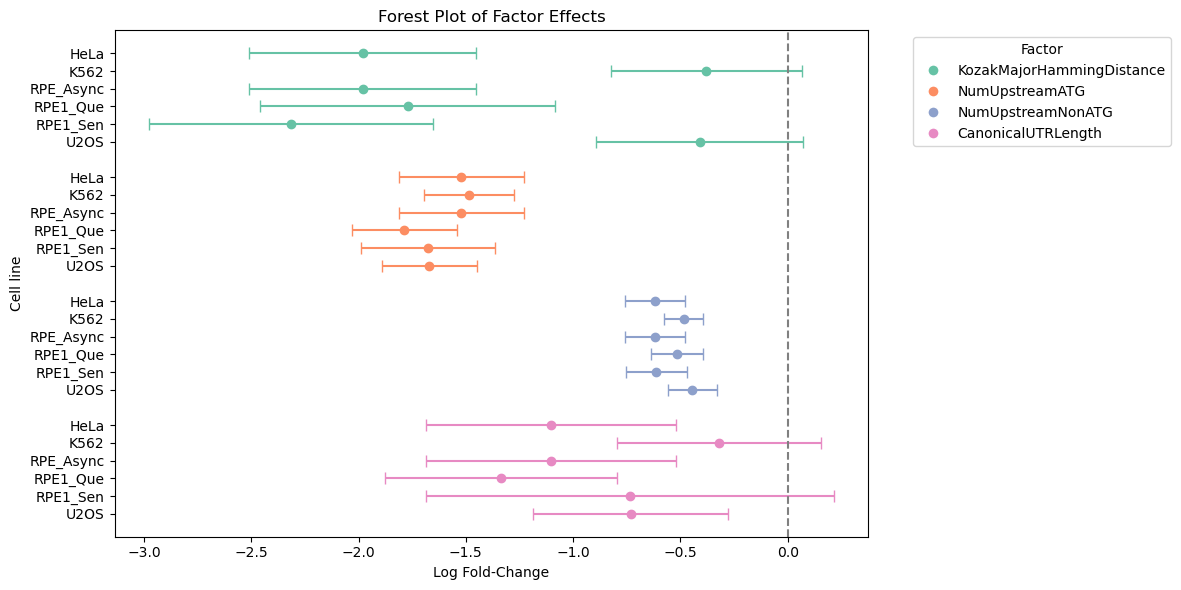

In [ ]:
fold_change_table = compute_fold_changes(
    model,
    # ['KozakMajorHammingDistance', 'NumUpstreamATG', 'NumUpstreamNonATG', 'CanonicalUTRLength', 'GCContentCanonicalUTR'],
    ['KozakMajorHammingDistance', 'NumUpstreamATG', 'NumUpstreamNonATG', 'CanonicalUTRLength'],
    ['HeLa', 'K562', 'RPE_Async', 'RPE1_Que', 'RPE1_Sen', 'U2OS'], 'HeLa'
)
plot_forest(fold_change_table, figsize=(12, 6))

## Step 5: Compare to Random Forest

In [79]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

features = ['KozakMajorHammingDistance', 'NumUpstreamATG', 'NumUpstreamNonATG', 'CanonicalUTRLength']
cell_lines = feature_table['Sample'].unique()

rf_models = {}
feature_importances = {}

for cl in tqdm(cell_lines):
    df_cl = feature_table[feature_table['Sample'] == cl]
    X = df_cl[features]
    y = np.log2(df_cl['TISCounts']+1) - df_cl['GeneRNASeqLogRPM']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    rf = RandomForestRegressor(n_estimators=1000, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    rf_models[cl] = rf
    feature_importances[cl] = pd.Series(rf.feature_importances_, index=features)
    
importance_df = pd.DataFrame(feature_importances)

100%|██████████| 6/6 [01:33<00:00, 15.65s/it]


<Axes: xlabel='Importance', ylabel='Metric'>

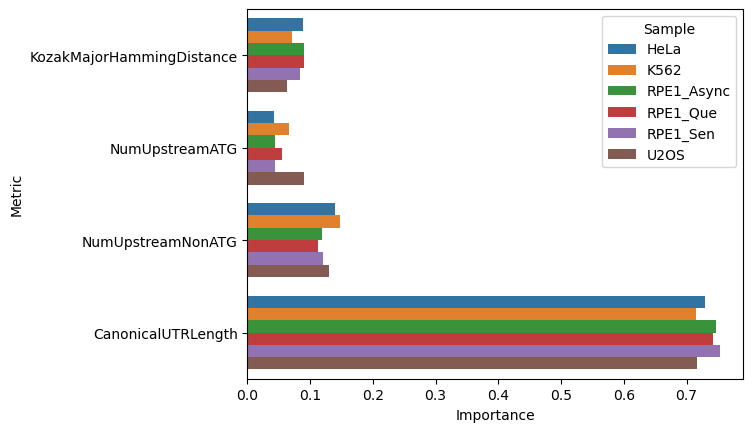

In [80]:
sns.barplot(
    importance_df.melt(ignore_index=False, var_name='Sample', value_name='Importance').reset_index(names=['Metric']),
    x='Importance', y='Metric', hue='Sample'
)

In [ ]:
all_replicate_tis_df.sort_values()

,Sample,Replicate,Gid,Tid,Symbol,GeneType,GenomePos,GenomeStart,Start,StartCodon,TisType,RecatTISType,TISGroup,TISCounts,NormTISCounts,GeneRNASeqCounts,TotalRNASeqCounts,AALen,MANE_Select,transcript_support_level,Imputed,AASeq
0,HeLa,rep1,ENSG00000188976.12,ENST00000327044.7,NOC2L,protein_coding,chr1:944693-959240:-,chr1:959240,16.0,ATG,Annotated,Annotated,3,14,4.658826,565.0,3005049,749.0,True,1.0,False,MAAAGSRKRRLAELTVDEFLASGFDSESESESENSPQAETREAREA...
1,HeLa,rep1,ENSG00000188976.12,ENST00000487214.1,NOC2L,protein_coding,chr1:954456-959240:-,chr1:959240,69.0,ATG,Novel:Known,Other,4,14,4.658826,565.0,3005049,254.0,False,3.0,False,MAAAGSRKRRLAELTVDEFLASGFDSESESESENSPQAETREAREA...
2,HeLa,rep1,ENSG00000188976.12,ENST00000487214.1,NOC2L,protein_coding,chr1:954456-959219:-,chr1:959219,90.0,AAG,Novel:CDSFrameOverlap,Other,4,50,16.638664,565.0,3005049,247.0,False,3.0,False,KRRLAELTVDEFLASGFDSESESESENSPQAETREAREAARSPDKP...
3,HeLa,rep1,ENSG00000187608.11,ENST00000624697.4,ISG15,protein_coding,chr1:1013998-1014478:+,chr1:1013998,245.0,GTG,Extended:CDSFrameOverlap,Extended,1,10,3.327733,72.0,3005049,159.0,False,3.0,False,VKMLAGNEFQVSLSSSMSVSELKAQITQKIGVHAFQQRLAVHPSGV...
4,HeLa,rep1,ENSG00000187608.11,ENST00000649529.1,ISG15,protein_coding,chr1:1013546-1014478:+,chr1:1013546,50.0,GTG,Extended,Extended,3,45,14.974797,72.0,3005049,174.0,True,NaN,False,VAHSPQPTAMGWDLTVKMLAGNEFQVSLSSSMSVSELKAQITQKIG...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430121,U2OS,rep2,ENSG00000130826.20,ENST00000369550.10,DKC1,protein_coding,chrX:154762966-154776864:+,chrX:154762966,102.0,ATG,Annotated,Annotated,0,0,0.000000,3522.0,13731484,514.0,True,1.0,True,MADAEVIILPKKHKKKKERKSLPEEDVAEIQHAEEFLIKPESKVAK...
430122,U2OS,rep2,ENSG00000182712.16,ENST00000369479.1,CMC4,protein_coding,chrX:155061846-155064023:-,chrX:155064023,442.0,ATG,Annotated,Annotated,0,0,0.000000,140.0,13731484,68.0,False,3.0,True,MPQKDPCQKQACEIQKCLQANSYMESKCQAVIQELRKCCAQYPKGR...
430123,U2OS,rep2,ENSG00000185515.16,ENST00000369462.5,BRCC3,protein_coding,chrX:155071528-155120147:+,chrX:155071528,25.0,ATG,Annotated,Annotated,0,0,0.000000,354.0,13731484,316.0,False,1.0,True,MAVQVVQAVQAVHLESDAFLVCLNHALSTEKEEVMGLCIGELNDDT...
430124,U2OS,rep2,ENSG00000185515.16,ENST00000330045.12,BRCC3,protein_coding,chrX:155071528-155120147:+,chrX:155071528,20.0,ATG,Annotated,Annotated,0,0,0.000000,354.0,13731484,291.0,True,1.0,True,MAVQVVQAVQAVHLESDAFLVCLNHALSTEKEEVMGLCIGELNDDT...


# GLM Model 2: add more factors (GC content)

In [83]:
model2 = smf.glm(
    formula="""
    TISCounts ~ 
        KozakMajorHammingDistance +
        NumUpstreamATG +
        NumUpstreamNonATG +
        CanonicalUTRLength +
        GCContentCanonicalUTR + 
        Sample +
        KozakMajorHammingDistance:Sample +
        NumUpstreamATG:Sample +
        NumUpstreamNonATG:Sample +
        CanonicalUTRLength:Sample + 
        GCContentCanonicalUTR:Sample
    """,
    # formula="""
    # TISCounts ~ 
    #     KozakMajorHammingDistance +
    #     NumUpstreamATG +
    #     NumUpstreamNonATG +
    #     CanonicalUTRLength +
    #     Sample +
    #     KozakMajorHammingDistance:Sample +
    #     NumUpstreamATG:Sample +
    #     NumUpstreamNonATG:Sample +
    #     CanonicalUTRLength:Sample
    # """,
    data=feature_table,
    family=sm.families.NegativeBinomial(),
    offset=feature_table["GeneRNASeqLogRPM"]
).fit(cov_type='HC0')

print(model2.summary())

/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:              TISCounts   No. Observations:               138190
Model:                            GLM   Df Residuals:                   138154
Model Family:        NegativeBinomial   Df Model:                           35
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -9.6884e+05
Date:                Fri, 20 Mar 2026   Deviance:                   9.3611e+05
Time:                        16:10:14   Pearson chi2:                 1.92e+08
No. Iterations:                   100   Pseudo R-squ. (CS):             0.9000
Covariance Type:                  HC0                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

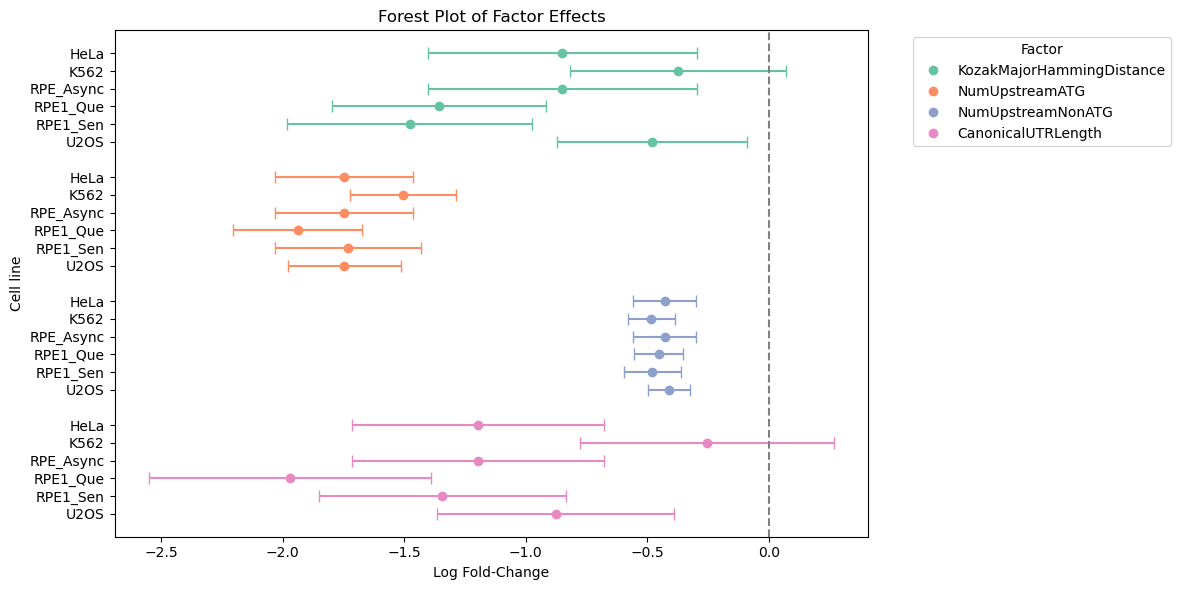

In [ ]:
fold_change_table2 = compute_fold_changes(
    model2, 
    # ['KozakMajorHammingDistance', 'NumUpstreamATG', 'NumUpstreamNonATG', 'CanonicalUTRLength', 'GCContentCanonicalUTR'],
    ['KozakMajorHammingDistance', 'NumUpstreamATG', 'NumUpstreamNonATG', 'CanonicalUTRLength'],
    ['HeLa', 'K562', 'RPE_Async', 'RPE1_Que', 'RPE1_Sen', 'U2OS'], 'HeLa'
)
plot_forest(fold_change_table2, figsize=(12, 6))

# GLM Model 3: use complete Kozak sequence

In [20]:
model3 = smf.glm(
    formula="""
    TISCounts ~ 
        KozakHammingDistance +
        NumUpstreamATG +
        NumUpstreamNonATG +
        CanonicalUTRLength +
        GCContentCanonicalUTR + 
        Sample +
        KozakHammingDistance:Sample +
        NumUpstreamATG:Sample +
        NumUpstreamNonATG:Sample +
        CanonicalUTRLength:Sample + 
        GCContentCanonicalUTR:Sample
    """,
    # formula="""
    # TISCounts ~ 
    #     KozakMajorHammingDistance +
    #     NumUpstreamATG +
    #     NumUpstreamNonATG +
    #     CanonicalUTRLength +
    #     Sample +
    #     KozakMajorHammingDistance:Sample +
    #     NumUpstreamATG:Sample +
    #     NumUpstreamNonATG:Sample +
    #     CanonicalUTRLength:Sample
    # """,
    data=feature_table,
    family=sm.families.NegativeBinomial(),
    offset=feature_table["GeneRNASeqLogRPM"]
).fit(cov_type='HC0')

print(model3.summary())

/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:              TISCounts   No. Observations:               138190
Model:                            GLM   Df Residuals:                   138154
Model Family:        NegativeBinomial   Df Model:                           35
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -9.5764e+05
Date:                Tue, 24 Mar 2026   Deviance:                   9.1371e+05
Time:                        01:47:55   Pearson chi2:                 1.86e+08
No. Iterations:                   100   Pseudo R-squ. (CS):             0.9150
Covariance Type:                  HC0                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

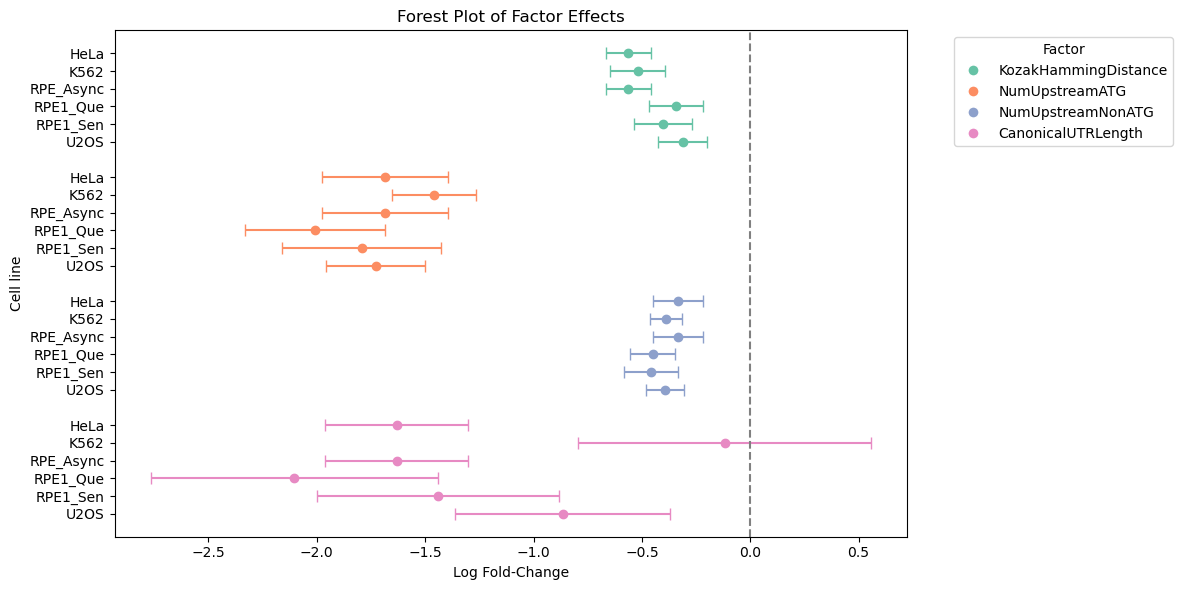

In [25]:
fold_change_table3 = compute_fold_changes(
    model3,  
    # ['KozakHammingDistance', 'NumUpstreamATG', 'NumUpstreamNonATG', 'CanonicalUTRLength', 'GCContentCanonicalUTR'],
    ['KozakHammingDistance', 'NumUpstreamATG', 'NumUpstreamNonATG', 'CanonicalUTRLength'],
    ['HeLa', 'K562', 'RPE_Async', 'RPE1_Que', 'RPE1_Sen', 'U2OS'], 'HeLa'
)
plot_forest(fold_change_table3, figsize=(12, 6))

# Model 4: Use full Kozak without GC content

In [26]:
model4 = smf.glm(
    formula="""
    TISCounts ~ 
        KozakHammingDistance +
        NumUpstreamATG +
        NumUpstreamNonATG +
        CanonicalUTRLength +
        Sample +
        KozakHammingDistance:Sample +
        NumUpstreamATG:Sample +
        NumUpstreamNonATG:Sample +
        CanonicalUTRLength:Sample
    """,
    # formula="""
    # TISCounts ~ 
    #     KozakMajorHammingDistance +
    #     NumUpstreamATG +
    #     NumUpstreamNonATG +
    #     CanonicalUTRLength +
    #     Sample +
    #     KozakMajorHammingDistance:Sample +
    #     NumUpstreamATG:Sample +
    #     NumUpstreamNonATG:Sample +
    #     CanonicalUTRLength:Sample
    # """,
    data=feature_table,
    family=sm.families.NegativeBinomial(),
    offset=feature_table["GeneRNASeqLogRPM"]
).fit(cov_type='HC0')

print(model4.summary())

/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:              TISCounts   No. Observations:               138190
Model:                            GLM   Df Residuals:                   138160
Model Family:        NegativeBinomial   Df Model:                           29
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.0116e+06
Date:                Tue, 24 Mar 2026   Deviance:                   1.0216e+06
Time:                        01:50:07   Pearson chi2:                 4.09e+08
No. Iterations:                   100   Pseudo R-squ. (CS):             0.8144
Covariance Type:                  HC0                                         
                                                coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

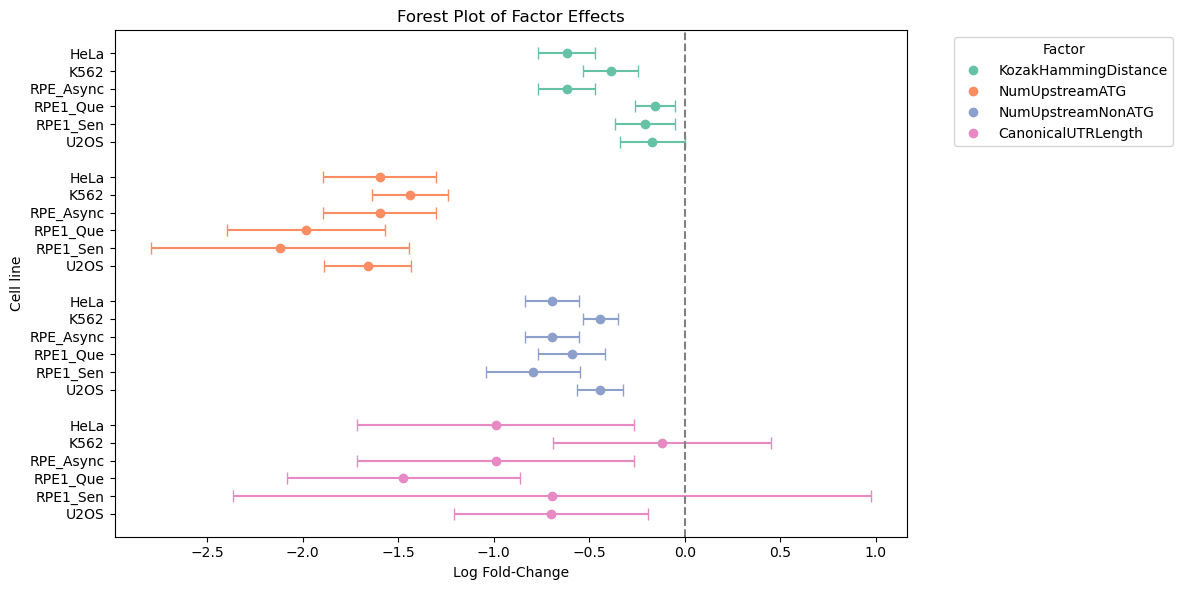

In [27]:
fold_change_table4 = compute_fold_changes(
    model4, 
    # ['KozakHammingDistance', 'NumUpstreamATG', 'NumUpstreamNonATG', 'CanonicalUTRLength', 'GCContentCanonicalUTR'],
    ['KozakHammingDistance', 'NumUpstreamATG', 'NumUpstreamNonATG', 'CanonicalUTRLength'],
    ['HeLa', 'K562', 'RPE_Async', 'RPE1_Que', 'RPE1_Sen', 'U2OS'], 'HeLa'
)
plot_forest(fold_change_table4, figsize=(12, 6))